In [ ]:
from google.colab import drive
import os

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

print("Drive ready")

Mounted at /content/drive
Drive ready


In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/seal_tracking_colab"

DATA_DIR = f"{PROJECT_DIR}/data"
VIDEO_DIR = f"{DATA_DIR}/raw_videos"
FRAME_DIR = f"{DATA_DIR}/frames"

OUTPUT_DIR = f"{PROJECT_DIR}/outputs"
FIGURE_DIR = f"{OUTPUT_DIR}/figures"
VIDEO_OUTPUT_DIR = f"{OUTPUT_DIR}/videos"

In [ ]:
from pathlib import Path

for path in [FRAME_DIR, FIGURE_DIR, VIDEO_OUTPUT_DIR]:
    Path(path).mkdir(parents=True, exist_ok=True)

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

import torch
import torchvision.transforms as transforms

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
model = model.to(device)
model.eval()

print("Model loaded on:", device)

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Model loaded on: cuda


In [ ]:
video_path = Path(VIDEO_DIR) / "seal_01.mp4"
output_frame_dir = Path(FRAME_DIR) / "video_01"
output_frame_dir.mkdir(parents=True, exist_ok=True)

cap = cv2.VideoCapture(str(video_path))

frame_interval = 10
frame_count = 0
saved_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_count % frame_interval == 0:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame_name = output_frame_dir / f"frame_{saved_count:04d}.jpg"
        Image.fromarray(frame_rgb).save(frame_name)
        saved_count += 1

    frame_count += 1

cap.release()

print("Saved frames:", saved_count)

Saved frames: 32


/content/drive/MyDrive/seal_tracking_colab/data/frames/video_01/frame_0000.jpg


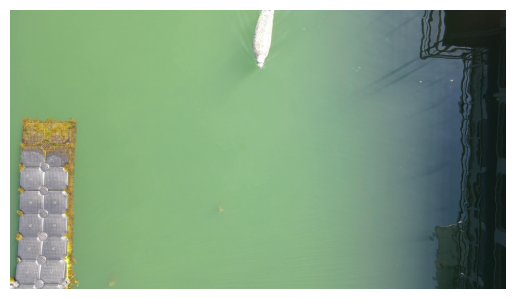

In [ ]:
frame_paths = sorted(output_frame_dir.glob("*.jpg"))

image_path = frame_paths[0]
print(image_path)

image = Image.open(image_path).convert("RGB")
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
dense_frames_dir = Path(FRAME_DIR) / "video_01_dense"
dense_frames_dir.mkdir(parents=True, exist_ok=True)

cap = cv2.VideoCapture(video_path)

frame_interval = 3
frame_idx = 0
saved_count = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    if frame_idx % frame_interval == 0:
        frame_path = dense_frames_dir / f"frame_{frame_idx:04d}.jpg"
        cv2.imwrite(str(frame_path), frame)
        saved_count += 1

    frame_idx += 1

cap.release()

print(f"Saved {saved_count} dense frames")

Saved 106 dense frames


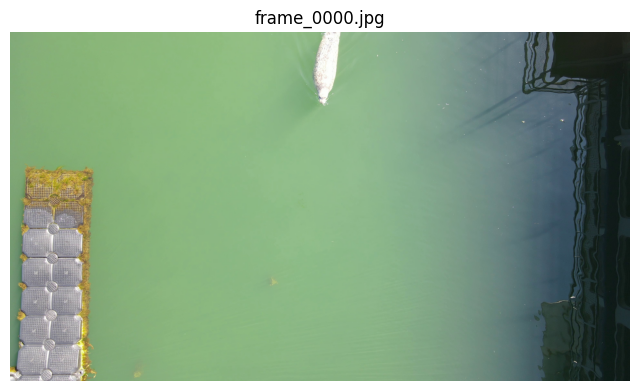

In [ ]:
dense_frame_paths = sorted(dense_frames_dir.glob("*.jpg"))

image_path = dense_frame_paths[0]
image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title(image_path.name)
plt.axis("off")
plt.show()

Reference frame fixed as:
/content/drive/MyDrive/seal_tracking_colab/data/frames/video_01_dense/frame_0000.jpg


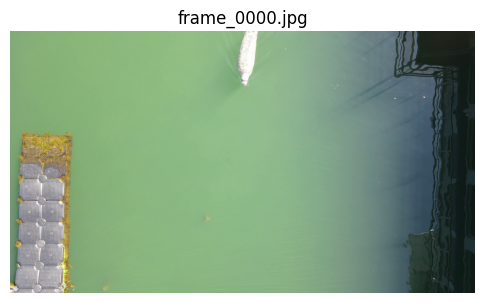

In [ ]:
reference_image_path = dense_frame_paths[0]

print("Reference frame fixed as:")
print(reference_image_path)

image_check = Image.open(reference_image_path).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(image_check)
plt.title(reference_image_path.name)
plt.axis("off")
plt.show()

In [ ]:
def extract_dino_patch_features(image_path, model, transform, device):
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        features = model.forward_features(image_tensor)

    patch_tokens = features["x_norm_patchtokens"]

    batch_size, num_patches, feature_dim = patch_tokens.shape
    grid_size = int(num_patches ** 0.5)

    patch_grid = patch_tokens.reshape(batch_size, grid_size, grid_size, feature_dim)
    patch_features = patch_grid[0].cpu().numpy()

    return image, patch_features, grid_size

In [ ]:
def compute_similarity_map(patch_features, reference_feature):
    grid_size = patch_features.shape[0]
    similarity_map = np.zeros((grid_size, grid_size))

    for y in range(grid_size):
        for x in range(grid_size):
            current_feature = patch_features[y, x]

            similarity = np.dot(reference_feature, current_feature) / (
                np.linalg.norm(reference_feature) * np.linalg.norm(current_feature)
            )

            similarity_map[y, x] = similarity

    return similarity_map

In [ ]:
def get_bbox_from_topk(similarity_map, top_percent=5):
    flat = similarity_map.flatten()

    cutoff = np.percentile(flat, 100 - top_percent)

    binary_mask = similarity_map >= cutoff

    ys, xs = np.where(binary_mask)

    if len(xs) == 0 or len(ys) == 0:
        return None, binary_mask

    x_min = xs.min()
    x_max = xs.max()
    y_min = ys.min()
    y_max = ys.max()

    return (x_min, y_min, x_max, y_max), binary_mask

In [ ]:
def get_bbox_from_topk_component(similarity_map, top_percent=3):
    valid_mask = similarity_map > -0.5
    valid_values = similarity_map[valid_mask]

    if len(valid_values) == 0:
        return None, np.zeros_like(similarity_map, dtype=bool)

    cutoff = np.percentile(valid_values, 100 - top_percent)
    binary_mask = (similarity_map >= cutoff) & valid_mask

    num_labels, labels = cv2.connectedComponents(binary_mask.astype(np.uint8))

    if num_labels <= 1:
        return None, binary_mask

    max_y, max_x = np.unravel_index(np.argmax(similarity_map), similarity_map.shape)
    target_label = labels[max_y, max_x]

    if target_label == 0:
        return None, binary_mask

    component_mask = labels == target_label

    ys, xs = np.where(component_mask)

    x_min = xs.min()
    x_max = xs.max()
    y_min = ys.min()
    y_max = ys.max()

    return (x_min, y_min, x_max, y_max), component_mask

In [ ]:
def get_similarity_confidence(similarity_map, top_k=20):
    flat = similarity_map.flatten()
    top_values = np.sort(flat)[-top_k:]

    max_similarity = flat.max()
    mean_top_similarity = top_values.mean()

    return max_similarity, mean_top_similarity

In [ ]:
def get_bbox_center(bbox):
    x_min, y_min, x_max, y_max = bbox

    center_x = (x_min + x_max) / 2
    center_y = (y_min + y_max) / 2

    return center_x, center_y

In [ ]:
def apply_motion_constraint(similarity_map, previous_bbox, search_radius=6):
    grid_size = similarity_map.shape[0]

    if previous_bbox is None:
        return similarity_map

    center_x, center_y = get_bbox_center(previous_bbox)

    constrained_map = np.full_like(similarity_map, -1.0)

    x_min = max(0, int(center_x - search_radius))
    x_max = min(grid_size, int(center_x + search_radius + 1))

    y_min = max(0, int(center_y - search_radius))
    y_max = min(grid_size, int(center_y + search_radius + 1))

    constrained_map[y_min:y_max, x_min:x_max] = similarity_map[y_min:y_max, x_min:x_max]

    return constrained_map

In [ ]:
def patch_bbox_to_image_bbox(bbox, grid_size, image_size=518):
    x_min, y_min, x_max, y_max = bbox

    patch_size = image_size / grid_size

    x_min_img = int(x_min * patch_size)
    x_max_img = int((x_max + 1) * patch_size)

    y_min_img = int(y_min * patch_size)
    y_max_img = int((y_max + 1) * patch_size)

    return x_min_img, y_min_img, x_max_img, y_max_img

### For 518 * 518

In [ ]:
selected_frame_paths_518 = dense_frame_paths

print("Total dense frames:", len(selected_frame_paths_518))

Total dense frames: 106


In [ ]:
transform_518 = transforms.Compose([
    transforms.Resize((518, 518)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
image_518, patch_features_518, grid_size_518 = extract_dino_patch_features(
    reference_image_path,
    model,
    transform_518,
    device
)

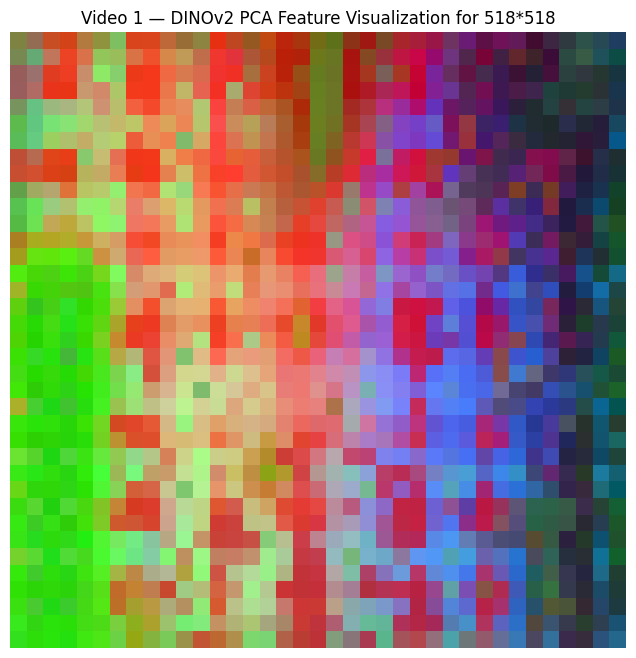

In [ ]:
from sklearn.decomposition import PCA

feature_dim_518 = patch_features_518.shape[-1]

flattened_features_518 = patch_features_518.reshape(-1, feature_dim_518)

pca = PCA(n_components=3)
pca_features_518 = pca.fit_transform(flattened_features_518)

pca_min_518 = pca_features_518.min(axis=0)
pca_max_518 = pca_features_518.max(axis=0)

pca_features_normalized_518 = (pca_features_518 - pca_min_518) / (pca_max_518 - pca_min_518)

pca_image_518 = pca_features_normalized_518.reshape(grid_size_518, grid_size_518, 3)

plt.figure(figsize=(8, 8))
plt.imshow(pca_image_518)
plt.title("Video 1 — DINOv2 PCA Feature Visualization for 518*518")
plt.axis("off")
plt.show()

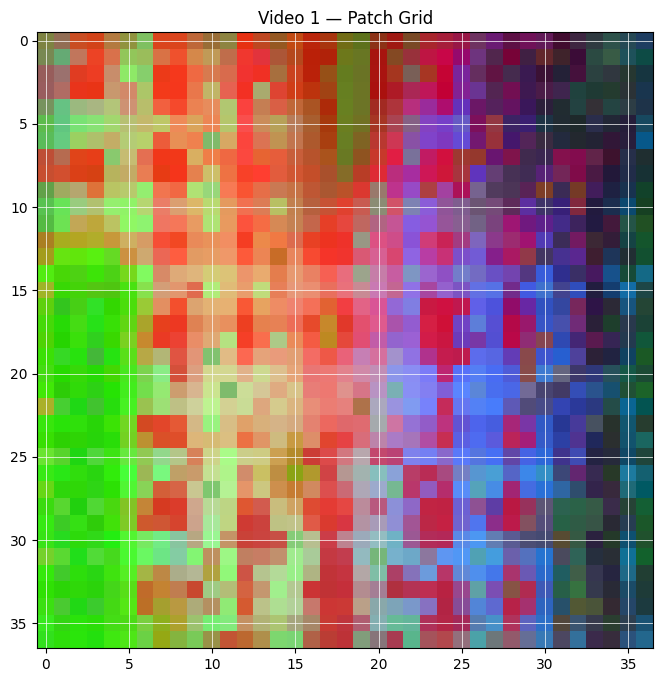

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(pca_image_518)

plt.xticks(range(0, grid_size_518, 5))
plt.yticks(range(0, grid_size_518, 5))
plt.grid(color="white", linewidth=0.5)

plt.title("Video 1 — Patch Grid")
plt.show()

In [ ]:
seal_points_518 = [
   (0, 19),
   (1, 18),
   (2, 19),
   (3, 18),
   (6, 18),
   (4, 19),
   (5, 18)
]

In [ ]:
reference_features_518 = []

for y, x in seal_points_518:
    reference_features_518.append(patch_features_518[y, x])

reference_feature_518 = np.mean(reference_features_518, axis=0)

print(reference_feature_518.shape)

(384,)


In [ ]:
similarity_map_518 = compute_similarity_map(
    patch_features_518,
    reference_feature_518
)

print(similarity_map_518.shape)

(37, 37)


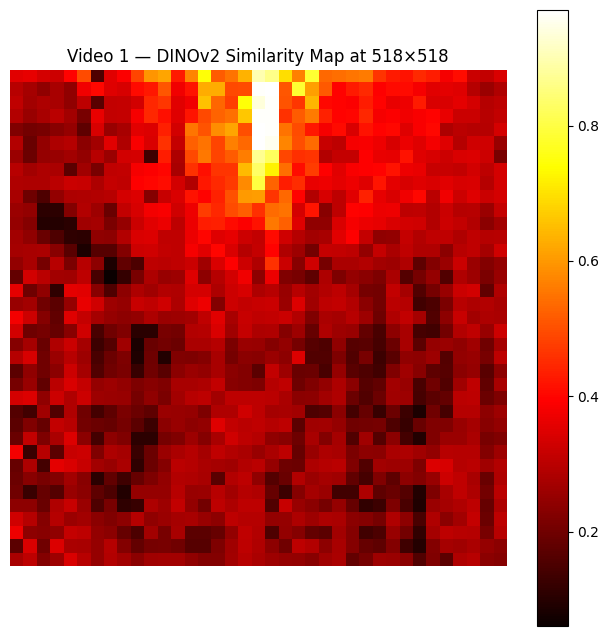

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(similarity_map_518, cmap="hot")
plt.colorbar()
plt.title("Video 1 — DINOv2 Similarity Map at 518×518")
plt.axis("off")
plt.show()

In [ ]:
top_percent = 3
confidence_threshold = 0.65
search_radius = 9

tracking_results_518 = []
previous_bbox = None

for frame_path in selected_frame_paths_518:

    image, patch_features_new, grid_size_new = extract_dino_patch_features(
        frame_path,
        model,
        transform_518,
        device
    )

    similarity_map_new = compute_similarity_map(
        patch_features_new,
        reference_feature_518
    )

    constrained_similarity_map = apply_motion_constraint(
        similarity_map_new,
        previous_bbox,
        search_radius=search_radius
    )

    max_sim, mean_top_sim = get_similarity_confidence(
        constrained_similarity_map
    )

    if mean_top_sim < confidence_threshold:
        bbox = None
        binary_mask = np.zeros_like(constrained_similarity_map, dtype=bool)

    else:
        bbox, binary_mask = get_bbox_from_topk(
            constrained_similarity_map,
            top_percent=top_percent
        )

    if bbox is not None:
        previous_bbox = bbox

    tracking_results_518.append({
        "image_path": frame_path,
        "image": image,
        "similarity_map": similarity_map_new,
        "constrained_similarity_map": constrained_similarity_map,
        "bbox": bbox,
        "binary_mask": binary_mask,
        "grid_size": grid_size_new,
        "max_similarity": max_sim,
        "mean_top_similarity": mean_top_sim
    })

print("Processed frames:", len(tracking_results_518))

Processed frames: 106


In [ ]:
import matplotlib.patches as patches

display_interval = 5

display_results_518 = tracking_results_518[::display_interval]

fig, axes = plt.subplots(
    len(display_results_518),
    2,
    figsize=(10, 4 * len(display_results_518))
)

for i, result in enumerate(display_results_518):

    image = result["image"].resize((518, 518))
    bbox = result["bbox"]

    axes[i, 0].imshow(image)
    axes[i, 0].set_title(result["image_path"].name)
    axes[i, 0].axis("off")

    if bbox is not None:

        x_min_img, y_min_img, x_max_img, y_max_img = patch_bbox_to_image_bbox(
            bbox,
            result["grid_size"],
            image_size=518
        )

        rect = patches.Rectangle(
            (x_min_img, y_min_img),
            x_max_img - x_min_img,
            y_max_img - y_min_img,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        axes[i, 0].add_patch(rect)

    axes[i, 1].imshow(
        result["constrained_similarity_map"],
        cmap="hot"
    )

    axes[i, 1].set_title("Motion-Constrained Similarity")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
output_video_dir = Path(VIDEO_OUTPUT_DIR)
output_video_dir.mkdir(parents=True, exist_ok=True)

output_video_path = output_video_dir / "seal_tracking_video_518_dinov2_motion_constrained.mp4"

fps = 10
image_size = 518

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
video_writer = cv2.VideoWriter(
    str(output_video_path),
    fourcc,
    fps,
    (image_size, image_size)
)

for result in tracking_results_518:
    image = result["image"].resize((image_size, image_size))
    frame = np.array(image)

    if result["bbox"] is not None:
        x_min_img, y_min_img, x_max_img, y_max_img = patch_bbox_to_image_bbox(
            result["bbox"],
            result["grid_size"],
            image_size=image_size
        )

        cv2.rectangle(
            frame,
            (x_min_img, y_min_img),
            (x_max_img, y_max_img),
            (255, 0, 0),
            2
        )

    frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
    video_writer.write(frame_bgr)

video_writer.release()

print("Saved video to:", output_video_path)

Saved video to: /content/drive/MyDrive/seal_tracking_colab/outputs/videos/seal_tracking_video_518_dinov2_motion_constrained.mp4


In [ ]:
import gc
import matplotlib.pyplot as plt

# Remove notebook outputs
from IPython.display import clear_output

plt.close("all")

# Delete variables if they exist
for var in list(globals().keys()):

    if (
        "tracking_results_518" in var
        or "display_results_518" in var
        or "image" in var
        or "similarity" in var
        or "patch" in var
        or "binary" in var
        or "bbox" in var
    ):
        try:
            del globals()[var]
        except:
            pass

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

clear_output(wait=True)

print("Cleanup finished")

Cleanup finished


### For 728 * 728

In [ ]:
selected_frame_paths_728 = dense_frame_paths

print("Total dense frames:", len(selected_frame_paths_728))

Total dense frames: 106


In [ ]:
transform_728 = transforms.Compose([
    transforms.Resize((728, 728)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
image_728, patch_features_728, grid_size_728 = extract_dino_patch_features(
    reference_image_path,
    model,
    transform_728,
    device
)

print("728 features:", patch_features_728.shape)
print("728 grid:", grid_size_728)

728 features: (52, 52, 384)
728 grid: 52


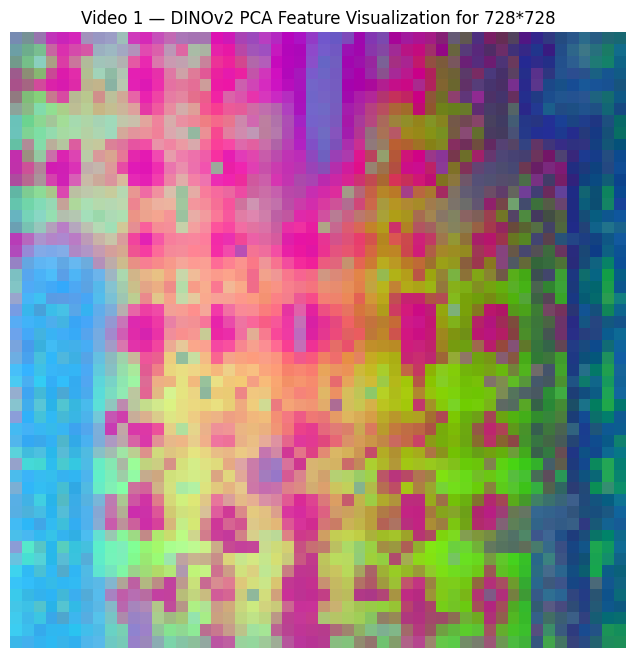

In [ ]:
from sklearn.decomposition import PCA

feature_dim_728 = patch_features_728.shape[-1]

flattened_features_728 = patch_features_728.reshape(-1, feature_dim_728)

pca = PCA(n_components=3)
pca_features_728 = pca.fit_transform(flattened_features_728)

pca_min_728 = pca_features_728.min(axis=0)
pca_max_728 = pca_features_728.max(axis=0)

pca_features_normalized_728 = (pca_features_728 - pca_min_728) / (pca_max_728 - pca_min_728)

pca_image_728 = pca_features_normalized_728.reshape(grid_size_728, grid_size_728, 3)

plt.figure(figsize=(8, 8))
plt.imshow(pca_image_728)
plt.title("Video 1 — DINOv2 PCA Feature Visualization for 728*728")
plt.axis("off")
plt.show()

In [ ]:
scale = grid_size_728 / grid_size_518

seal_points_728 = [
    (round(y * scale), round(x * scale))
    for y, x in seal_points_518
]

print(seal_points_728)

[(0, 27), (1, 25), (3, 27), (4, 25), (8, 25), (6, 27), (7, 25)]


In [ ]:
reference_features_728 = []

for y, x in seal_points_728:
    reference_features_728.append(patch_features_728[y, x])

reference_feature_728 = np.mean(reference_features_728, axis=0)

print(reference_feature_728.shape)

(384,)


In [ ]:
similarity_map_728 = compute_similarity_map(
    patch_features_728,
    reference_feature_728
)

print(similarity_map_728.shape)

(52, 52)


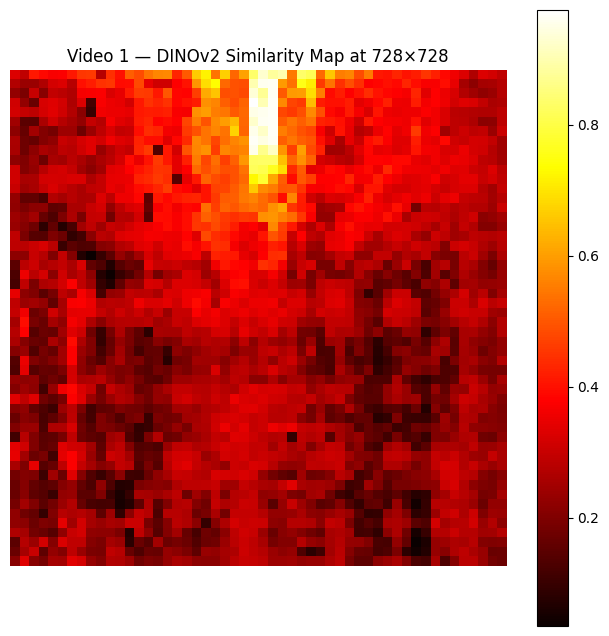

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(similarity_map_728, cmap="hot")
plt.colorbar()
plt.title("Video 1 — DINOv2 Similarity Map at 728×728")
plt.axis("off")
plt.show()

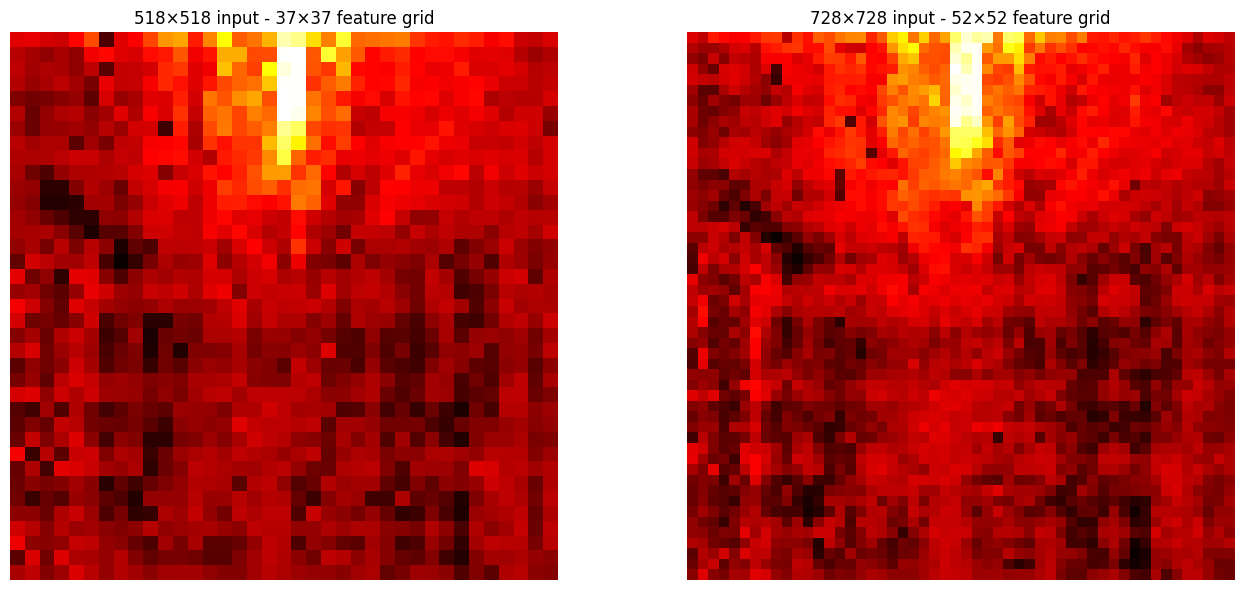

Figure saved


In [ ]:
import os

os.makedirs(FIGURE_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(similarity_map_518, cmap="hot")
axes[0].set_title("518×518 input - 37×37 feature grid")
axes[0].axis("off")

axes[1].imshow(similarity_map_728, cmap="hot")
axes[1].set_title("728×728 input - 52×52 feature grid")
axes[1].axis("off")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/resolution_similarity_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved")

In [ ]:
import os

os.makedirs(FIGURE_DIR, exist_ok=True)

plt.savefig(
    f"{FIGURE_DIR}/similarity_heatmap_comparison.png",
    bbox_inches="tight",
    dpi=300
)

print("Saved successfully")

Saved successfully


<Figure size 640x480 with 0 Axes>

In [ ]:
top_percent = 3
confidence_threshold = 0.65
search_radius = 13

tracking_results_728 = []
previous_bbox = None

for frame_path in selected_frame_paths_728:

    image, patch_features_new, grid_size_new = extract_dino_patch_features(
        frame_path,
        model,
        transform_728,
        device
    )

    similarity_map_new = compute_similarity_map(
        patch_features_new,
        reference_feature_728
    )

    constrained_similarity_map = apply_motion_constraint(
        similarity_map_new,
        previous_bbox,
        search_radius=search_radius
    )

    max_sim, mean_top_sim = get_similarity_confidence(
        constrained_similarity_map
    )

    if mean_top_sim < confidence_threshold:
        bbox = None
        binary_mask = np.zeros_like(constrained_similarity_map, dtype=bool)

    else:
        bbox, binary_mask = get_bbox_from_topk(
            constrained_similarity_map,
            top_percent=top_percent
        )

    if bbox is not None:
        previous_bbox = bbox

    tracking_results_728.append({
        "image_path": frame_path,
        "image": image,
        "similarity_map": similarity_map_new,
        "constrained_similarity_map": constrained_similarity_map,
        "bbox": bbox,
        "binary_mask": binary_mask,
        "grid_size": grid_size_new,
        "max_similarity": max_sim,
        "mean_top_similarity": mean_top_sim
    })

print("Processed frames:", len(tracking_results_728))

Processed frames: 106


In [ ]:
import matplotlib.patches as patches

display_interval = 5

display_results_728 = tracking_results_728[::display_interval]

fig, axes = plt.subplots(
    len(display_results_728),
    2,
    figsize=(10, 4 * len(display_results_728))
)

for i, result in enumerate(display_results_728):

    image = result["image"].resize((728, 728))
    bbox = result["bbox"]

    axes[i, 0].imshow(image)
    axes[i, 0].set_title(result["image_path"].name)
    axes[i, 0].axis("off")

    if bbox is not None:

        x_min_img, y_min_img, x_max_img, y_max_img = patch_bbox_to_image_bbox(
            bbox,
            result["grid_size"],
            image_size=728
        )

        rect = patches.Rectangle(
            (x_min_img, y_min_img),
            x_max_img - x_min_img,
            y_max_img - y_min_img,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        axes[i, 0].add_patch(rect)

    axes[i, 1].imshow(
        result["constrained_similarity_map"],
        cmap="hot"
    )

    axes[i, 1].set_title("Motion-Constrained Similarity")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
output_video_dir = Path(VIDEO_OUTPUT_DIR)
output_video_dir.mkdir(parents=True, exist_ok=True)

output_video_path = output_video_dir / "seal_tracking_video_728_dinov2_motion_constrained.mp4"

fps = 10
image_size = 728

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
video_writer = cv2.VideoWriter(
    str(output_video_path),
    fourcc,
    fps,
    (image_size, image_size)
)

for result in tracking_results_728:
    image = result["image"].resize((image_size, image_size))
    frame = np.array(image)

    if result["bbox"] is not None:
        x_min_img, y_min_img, x_max_img, y_max_img = patch_bbox_to_image_bbox(
            result["bbox"],
            result["grid_size"],
            image_size=image_size
        )

        cv2.rectangle(
            frame,
            (x_min_img, y_min_img),
            (x_max_img, y_max_img),
            (255, 0, 0),
            2
        )

    frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
    video_writer.write(frame_bgr)

video_writer.release()

print("Saved video to:", output_video_path)

Saved video to: /content/drive/MyDrive/seal_tracking_colab/outputs/videos/seal_tracking_video_728_dinov2_motion_constrained.mp4


### Video 2 (Background Similarity and orientation change)

In [ ]:
video_path_2 = Path(VIDEO_DIR) / "seal_02.mp4"
dense_frames_dir_2 = Path(FRAME_DIR) / "video_02_dense"
dense_frames_dir_2.mkdir(parents=True, exist_ok=True)

cap = cv2.VideoCapture(video_path_2)

frame_interval = 3
frame_idx = 0
saved_count = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    if frame_idx % frame_interval == 0:
        frame_path = dense_frames_dir_2 / f"frame_{frame_idx:04d}.jpg"
        cv2.imwrite(str(frame_path), frame)
        saved_count += 1

    frame_idx += 1

cap.release()

print(f"Saved {saved_count} dense frames")

Saved 107 dense frames


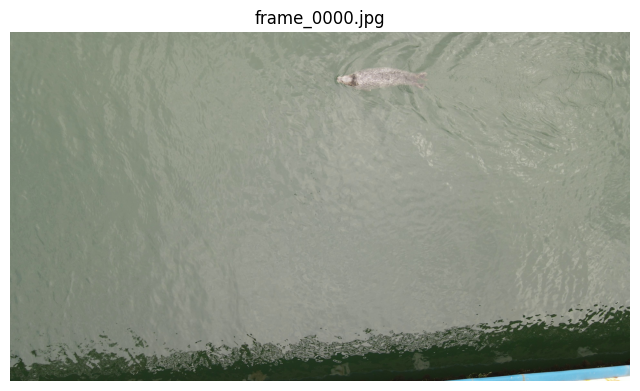

In [ ]:
dense_frame_paths_2 = sorted(dense_frames_dir_2.glob("*.jpg"))

image_path_2 = dense_frame_paths_2[0]
image_2 = Image.open(image_path_2).convert("RGB")

plt.figure(figsize=(8, 8))
plt.imshow(image_2)
plt.title(image_path_2.name)
plt.axis("off")
plt.show()

Reference frame fixed as:
/content/drive/MyDrive/seal_tracking_colab/data/frames/video_02_dense/frame_0000.jpg


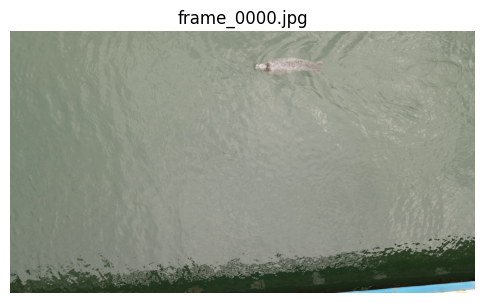

In [ ]:
reference_image_path_2 = dense_frame_paths_2[0]

print("Reference frame fixed as:")
print(reference_image_path_2)

image_check = Image.open(reference_image_path_2).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(image_check)
plt.title(reference_image_path_2.name)
plt.axis("off")
plt.show()

In [ ]:
selected_frame_paths_2_728 = dense_frame_paths_2

print("Total dense frames:", len(selected_frame_paths_2_728))

Total dense frames: 107


In [ ]:
transform_728 = transforms.Compose([
    transforms.Resize((728, 728)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
image_2_728, patch_features_2_728, grid_size_2_728 = extract_dino_patch_features(
    reference_image_path_2,
    model,
    transform_728,
    device
)

print("728 features:", patch_features_2_728.shape)
print("728 grid:", grid_size_2_728)

728 features: (52, 52, 384)
728 grid: 52


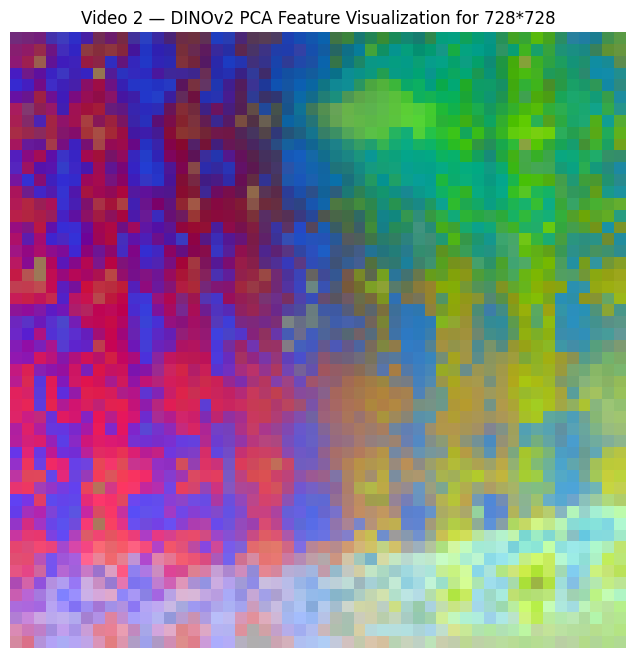

In [ ]:
from sklearn.decomposition import PCA

feature_dim_2_728 = patch_features_2_728.shape[-1]

flattened_features_2_728 = patch_features_2_728.reshape(-1, feature_dim_2_728)

pca = PCA(n_components=3)
pca_features_2_728 = pca.fit_transform(flattened_features_2_728)

pca_min_2_728 = pca_features_2_728.min(axis=0)
pca_max_2_728 = pca_features_2_728.max(axis=0)

pca_features_normalized_2_728 = (pca_features_2_728 - pca_min_2_728) / (pca_max_2_728 - pca_min_2_728)

pca_image_2_728 = pca_features_normalized_2_728.reshape(grid_size_2_728, grid_size_2_728, 3)

plt.figure(figsize=(8, 8))
plt.imshow(pca_image_2_728)
plt.title("Video 2 — DINOv2 PCA Feature Visualization for 728*728")
plt.axis("off")
plt.show()

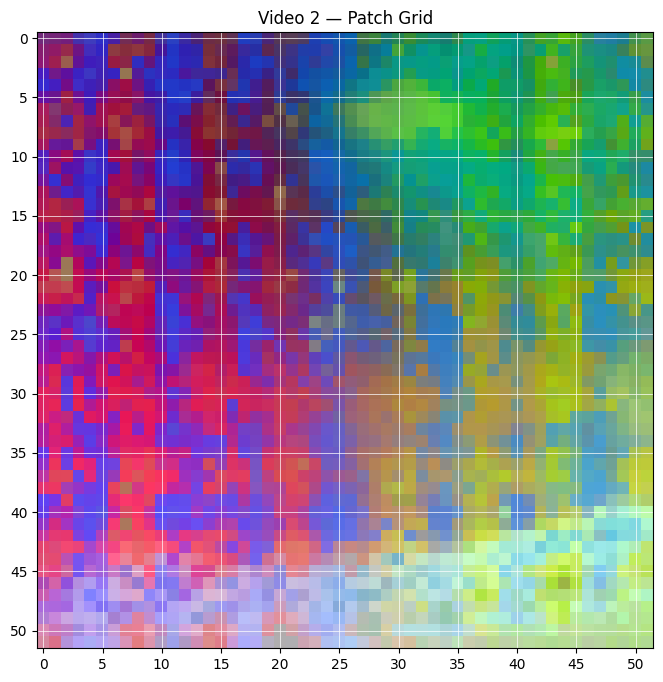

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(pca_image_2_728)

plt.xticks(range(0, grid_size_2_728, 5))
plt.yticks(range(0, grid_size_2_728, 5))
plt.grid(color="white", linewidth=0.5)

plt.title("Video 2 — Patch Grid")
plt.show()

In [ ]:
seal_points_2_728 = [
   (4,31),
   (5, 29),
   (5, 31),
   (6, 26),
   (6, 29),
   (6,32),
   (6, 34),
   (7,28),
   (7,34)
]

In [ ]:
reference_features_2_728 = []

for y, x in seal_points_2_728:
    reference_features_2_728.append(patch_features_2_728[y, x])

reference_feature_2_728 = np.mean(reference_features_2_728, axis=0)

print(reference_feature_2_728.shape)

(384,)


In [ ]:
similarity_map_2_728 = compute_similarity_map(
    patch_features_2_728,
    reference_feature_2_728
)

print(similarity_map_2_728.shape)


(52, 52)


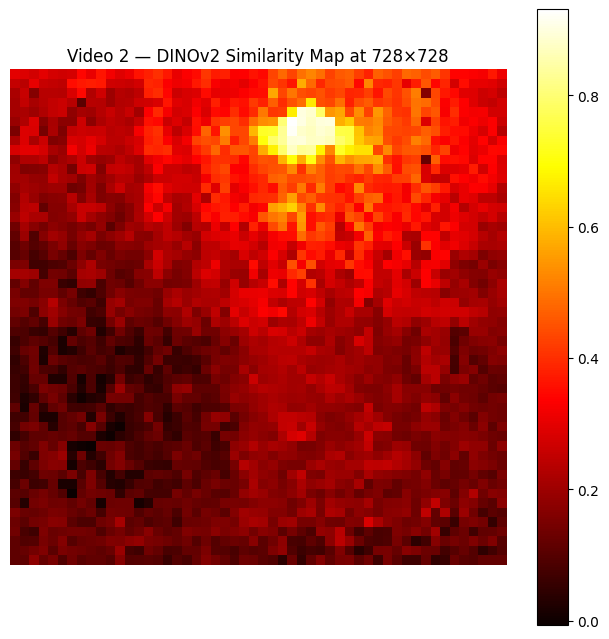

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(similarity_map_2_728, cmap="hot")
plt.colorbar()
plt.title("Video 2 — DINOv2 Similarity Map at 728×728")
plt.axis("off")
plt.show()

In [ ]:
top_percent = 3
confidence_threshold = 0.65
search_radius = 18

tracking_results_2_728 = []
previous_bbox = None

for frame_path in selected_frame_paths_2_728:

    image, patch_features_new, grid_size_new = extract_dino_patch_features(
        frame_path,
        model,
        transform_728,
        device
    )

    similarity_map_new = compute_similarity_map(
        patch_features_new,
        reference_feature_2_728
    )

    constrained_similarity_map = apply_motion_constraint(
        similarity_map_new,
        previous_bbox,
        search_radius=search_radius
    )

    max_sim, mean_top_sim = get_similarity_confidence(
        constrained_similarity_map
    )

    if mean_top_sim < confidence_threshold:
        bbox = None
        binary_mask = np.zeros_like(constrained_similarity_map, dtype=bool)

    else:
      bbox, binary_mask = get_bbox_from_topk_component(
          constrained_similarity_map,
          top_percent=top_percent
        )
        # bbox, binary_mask = get_bbox_from_topk(
        #     constrained_similarity_map,
        #     top_percent=top_percent
        # )

    if bbox is not None:
        previous_bbox = bbox

    tracking_results_2_728.append({
        "image_path": frame_path,
        "image": image,
        "similarity_map": similarity_map_new,
        "constrained_similarity_map": constrained_similarity_map,
        "bbox": bbox,
        "binary_mask": binary_mask,
        "grid_size": grid_size_new,
        "max_similarity": max_sim,
        "mean_top_similarity": mean_top_sim
    })

print("Processed frames:", len(tracking_results_2_728))

Processed frames: 107


In [ ]:
import matplotlib.patches as patches

display_interval = 10

display_results_2_728 = tracking_results_2_728[::display_interval]

fig, axes = plt.subplots(
    len(display_results_2_728),
    2,
    figsize=(10, 4 * len(display_results_2_728))
)

for i, result in enumerate(display_results_2_728):

    image = result["image"].resize((728, 728))
    bbox = result["bbox"]

    axes[i, 0].imshow(image)
    axes[i, 0].set_title(result["image_path"].name)
    axes[i, 0].axis("off")

    if bbox is not None:

        x_min_img, y_min_img, x_max_img, y_max_img = patch_bbox_to_image_bbox(
            bbox,
            result["grid_size"],
            image_size=728
        )

        rect = patches.Rectangle(
            (x_min_img, y_min_img),
            x_max_img - x_min_img,
            y_max_img - y_min_img,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        axes[i, 0].add_patch(rect)

    axes[i, 1].imshow(
        result["constrained_similarity_map"],
        cmap="hot"
    )

    axes[i, 1].set_title("Motion-Constrained Similarity")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
output_video_dir = Path(VIDEO_OUTPUT_DIR)
output_video_dir.mkdir(parents=True, exist_ok=True)

output_video_path = output_video_dir / "seal_tracking_video_2_728_motion_constrained.mp4"

fps = 10
image_size = 728

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
video_writer = cv2.VideoWriter(
    str(output_video_path),
    fourcc,
    fps,
    (image_size, image_size)
)

for result in tracking_results_2_728:
    image = result["image"].resize((image_size, image_size))
    frame = np.array(image)

    if result["bbox"] is not None:
        x_min_img, y_min_img, x_max_img, y_max_img = patch_bbox_to_image_bbox(
            result["bbox"],
            result["grid_size"],
            image_size=image_size
        )

        cv2.rectangle(
            frame,
            (x_min_img, y_min_img),
            (x_max_img, y_max_img),
            (255, 0, 0),
            2
        )

    frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
    video_writer.write(frame_bgr)

video_writer.release()

print("Saved video to:", output_video_path)

Saved video to: /content/drive/MyDrive/seal_tracking_colab/outputs/videos/seal_tracking_video_2_728_motion_constrained.mp4


In [ ]:
import gc
import matplotlib.pyplot as plt

# Remove notebook outputs
from IPython.display import clear_output

plt.close("all")

# Delete variables if they exist
for var in list(globals().keys()):

    if (
        "tracking_results" in var
        or "display_results" in var
        or "image" in var
        or "similarity" in var
        or "patch" in var
        or "binary" in var
        or "bbox" in var
    ):
        try:
            del globals()[var]
        except:
            pass

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

clear_output(wait=True)

print("Cleanup finished")

Cleanup finished
